In [19]:
import os
import json
import time
import argparse
from typing import Tuple, Optional
import re

import numpy as np
from scipy.optimize import minimize

#few and SEF imports
from few.waveform import GenerateEMRIWaveform
from few.waveform.waveform import SuperKludgeWaveform

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode.flux import KerrEccEqFlux
from few.utils.geodesic import get_fundamental_frequencies
from scipy.interpolate import CubicSpline
from scipy.integrate import cumulative_trapezoid
from few.utils.constants import MTSUN_SI

from fastlisaresponse import ResponseWrapper
from lisatools.detector import EqualArmlengthOrbits
from lisatools.sensitivity import get_sensitivity, A1TDISens, E1TDISens, T1TDISens
from stableemrifisher.utils import generate_PSD, inner_product
from stableemrifisher.fisher import StableEMRIFisher
import matplotlib.pyplot as plt

from config_paris import Config, ObjectiveTracker
from misc import *
from misc import fishinv

try:
    import cupy as cp
    xp=cp
except:
    xp=np
    print("CuPy not found, using NumPy instead. For GPU acceleration, please install CuPy.")

from inference import  prepare_true_waveform

[INFO] Finished loading modules and building ResponseWrapper
[INFO] Finished generating true waveform
shape check - waveform_true: (3, 6311629) PSD_funcs: (3, 3155814)
[TRUE] SNR: 44.679967
[TRUE] SNR - Channel 0: 31.680252
[TRUE] SNR - Channel 1: 31.413214
[TRUE] SNR - Channel 2: 2.423038
[INFO] Frequency resolution delta_f: 3.168754e-08 Hz, Number of frequency bins: 3155815
freq_max: 0.100000 Hz and Freq_min: 0.000000 Hz


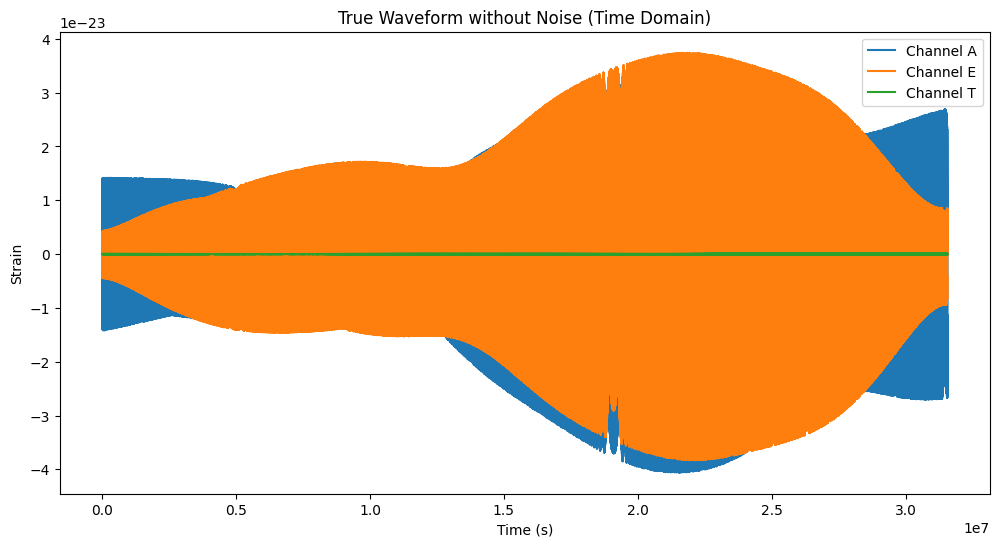

[INFO] Added noise to true waveform FFT

shape of waveform_true_fft after noise addition: (3, 3155814)


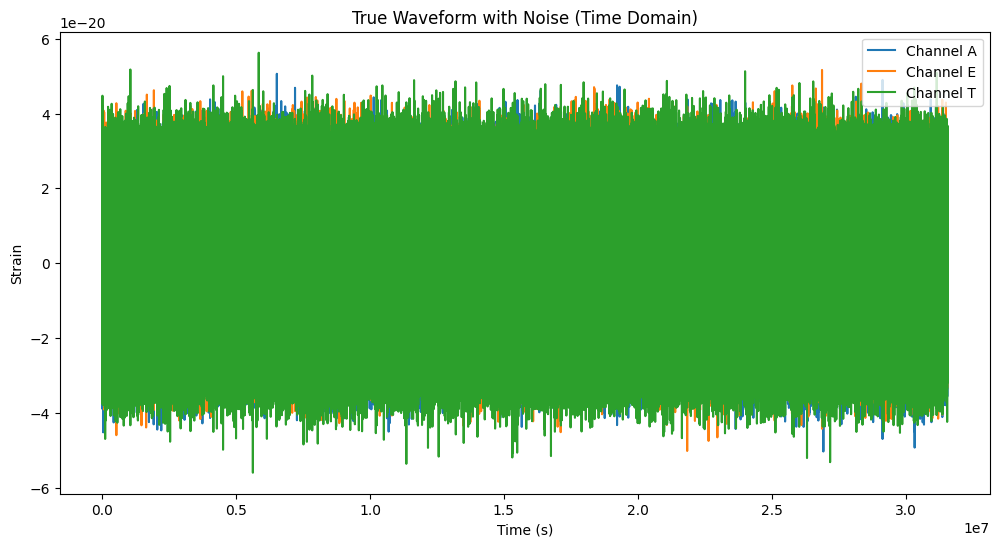

Length of PSD: 3155814


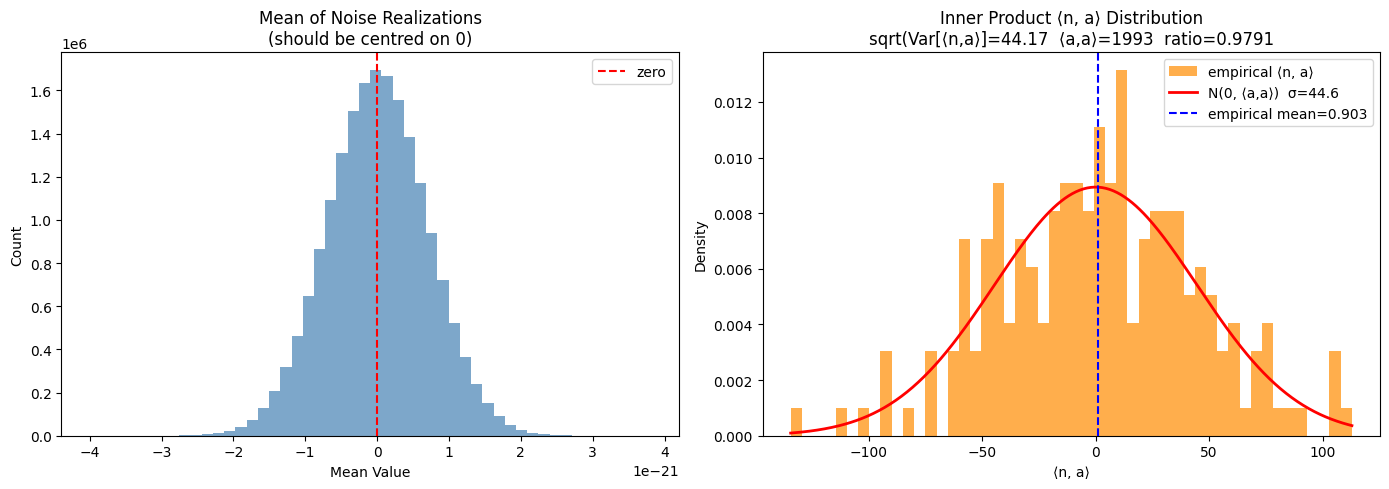

  Noise model consistency check
  Backend                : CuPy (GPU)
  Realizations           : 200
  N time samples         : 6311626  |  PSD bins passed: 3155813
  N (template samples)   : 6311629  →  aligned to 6311626
  Max |mean noise|       : 4.0032e-21  (expect ≈ 0)
  E[⟨n, a⟩]             : 9.0326e-01           (expect ≈ 0)
  Var[⟨n, a⟩]           : 1950.89
  ⟨a, a⟩                : 1992.53
  Ratio Var/⟨a,a⟩       : 0.979106          (expect ≈ 1.0)
Noise consistency check results: {'mean_noise': array([[-8.68921176e-22,  3.54543943e-22,  2.52559991e-22, ...,
         6.30125341e-22, -5.83403466e-22,  7.10403505e-22],
       [-2.08924216e-23,  4.32156119e-24,  1.78857121e-22, ...,
         1.02424805e-21,  2.71873085e-23,  2.46304456e-22],
       [ 5.81954774e-22, -8.54387829e-23,  7.93659288e-23, ...,
         1.00137071e-21, -1.06712954e-21, -1.78807266e-22]],
      shape=(3, 6311626)), 'inner_products': array([ 1.88766651e+01, -4.71163287e+01,  5.15812769e+01,  3.41924805e+0

{'m1': np.float64(1000000.0),
 'm2': np.float64(10.0),
 'a': np.float64(0.9),
 'p0': np.float64(7.5),
 'e0': np.float64(0.5),
 'Y0': np.float64(1.0),
 'dist': np.float64(5.0),
 'qS': np.float64(0.7853981633974483),
 'phiS': np.float64(1.0),
 'qK': np.float64(1.0),
 'phiK': np.float64(1.0471975511965976),
 'Phi_phi0': np.float64(0.9),
 'Phi_theta0': np.float64(0.5),
 'Phi_r0': np.float64(0.4),
 'dt': 5,
 'T': 1.0,
 'chi2': 0.0,
 'dev_1': 0.0,
 'dev_2': 0.0,
 'waveform_response': <fastlisaresponse.response.ResponseWrapper at 0x15528b5b7c50>,
 'PSD_funcs': array([[6.81763650e-35, 1.70440916e-35, 7.57515208e-36, ...,
         4.26636463e-39, 4.26636171e-39, 4.26635879e-39],
        [6.81763650e-35, 1.70440916e-35, 7.57515208e-36, ...,
         4.26636463e-39, 4.26636171e-39, 4.26635879e-39],
        [2.65994852e-56, 1.06395802e-55, 2.39388950e-55, ...,
         1.65107196e-39, 1.65106498e-39, 1.65105800e-39]],
       shape=(3, 3155814)),
 'waveform_true_fft': array([[-6.25689989e-15+4.0676

In [20]:
seed= 42   
param_names_to_infer = ['m1', 'm2', 'a', 'p0', 'e0', 'qS', 'phiS', 'Phi_phi0', 'Phi_r0']  
params_name = ["m1","m2","a","p0","e0","xI0","dist","qS","phiS","qK","phiK",
                         "Phi_phi0","Phi_theta0","Phi_r0"]      

params = np.array([1e6,1e1,0.9, 7.5,  5.00000000e-01,  1.00000000e+00,
          2.5,  np.pi/4,  1.0, 1,  np.pi/3,  9.00000000e-01, 5.00000000e-01,  4.00000000e-01])

signal_param = {"m1": 1e6,
    "m2": 10.0,
    "a": 0.9,
    "p0": 7.5,
    "e0": 0.5,
    "xI0": 1.0,
    "dist": 5.0,
    "qS": np.pi/4,
    "phiS": 1,
    "qK": 1,
    "phiK": np.pi/3,
    "Phi_phi0": 0.9,
    "Phi_theta0": 0.5,
    "Phi_r0": 4.00000000e-01,
}
signal_param_array = np.array(list(signal_param.values()))
dt = 5  #Time step for waveform generation; default 0.1s
T= 1.0

chi2 = 0.0 
dev_1 = 0.0
dev_2 = 0.0

emri_kwargs = {"T": T, "dt": dt,'chi2': chi2,'evolve_1PA': True,'evolve_primary': False,'evolve_2PA': False,'deviation_included': True,
                   'dev_1': dev_1, 'dev_2': dev_2}
add_kwargs = {'chi2': chi2,'evolve_1PA': True,'evolve_primary': False,'evolve_2PA': False,'deviation_included': True,
                   'dev_1': dev_1, 'dev_2': dev_2}

# if target_func in ('optimal_snr', 'optimal_snr_phase_max','time_max'):
        
ctx = prepare_true_waveform(signal_param_array, emri_kwargs, add_kwargs,add_noise=True, use_gpu=True,seed=seed)

snr_2 = inner_prod(ctx['waveform_true_fft_without_noise'], ctx['waveform_true_fft_without_noise'], ctx['PSD_funcs'], ctx['delta_f'], xp=xp)
ctx

In [21]:
use_gpu = True
channels = [A1TDISens, E1TDISens, T1TDISens]
noise_kwargs = [{"sens_fn": ch} for ch in channels]

sef = StableEMRIFisher(waveform_class=SuperKludgeWaveform,
                       waveform_class_kwargs = dict(sum_kwargs=dict(pad_output=False, odd_len=True)),
                       waveform_generator = GenerateEMRIWaveform,
                       waveform_generator_kwargs= dict(return_list=False),
                       ResponseWrapper=ResponseWrapper,
                       ResponseWrapper_kwargs = dict(Tobs=ctx['T'],
                                                    t0=10000.0,
                                                    dt=ctx['dt'],
                                                    index_lambda=8,
                                                    index_beta=7,
                                                    flip_hx=True,
                                                    is_ecliptic_latitude=False,
                                                    remove_garbage="zero",
                                                    orbits=EqualArmlengthOrbits(use_gpu=use_gpu),
                                                    force_backend = "cuda12x" if use_gpu else "cpu",
                                                    order=20,
                                                    tdi="2nd generation",
                                                    tdi_chan="AET"),
                       stats_for_nerds = True, use_gpu = use_gpu,
                       deriv_type='stable',
                       noise_model=get_sensitivity,
                       noise_kwargs=noise_kwargs,
                       channels=channels,
                       T = ctx['T'], dt = ctx['dt'],
                       stability_plot = False,
                       der_order = 6, Ndelta = 12,
                       plunge_check=True, return_derivatives=False
                       )
emri_kwargs = {"T":ctx['T'], "dt":ctx['dt']}



waveform shape: (3, 6311629)
wave ndim: 2
Computing SNR for parameters: (1000302.895908148, 10.00184726535304, 0.9001985943994095, 7.498766598193502, 0.4999556656327664, np.float64(1.0), np.float64(5.0), np.float64(0.7853981633974483), np.float64(1.0), np.float64(1.0), np.float64(1.0471975511965976), np.float64(0.9), np.float64(0.5), np.float64(0.4), 0.0, True, False, True, False, 0, 0)
SNR:  46.60466920888051
Body is not plunging, Fisher should be stable.
waveform shape: (3, 6311629)
wave ndim: 2
Computing SNR for parameters: (1000302.895908148, 10.00184726535304, 0.9001985943994095, 7.498766598193502, 0.4999556656327664, np.float64(1.0), np.float64(5.0), np.float64(0.7853981633974483), np.float64(1.0), np.float64(1.0), np.float64(1.0471975511965976), np.float64(0.9), np.float64(0.5), np.float64(0.4), 0.0, True, False, True, False, 0, 0)
Waveform Generated. SNR: 46.60466920888051
calculating stable deltas...
Gamma_ii for m1: 2274.388710207944
Gamma_ii for m1: 2274.3882422587517
Gamma_

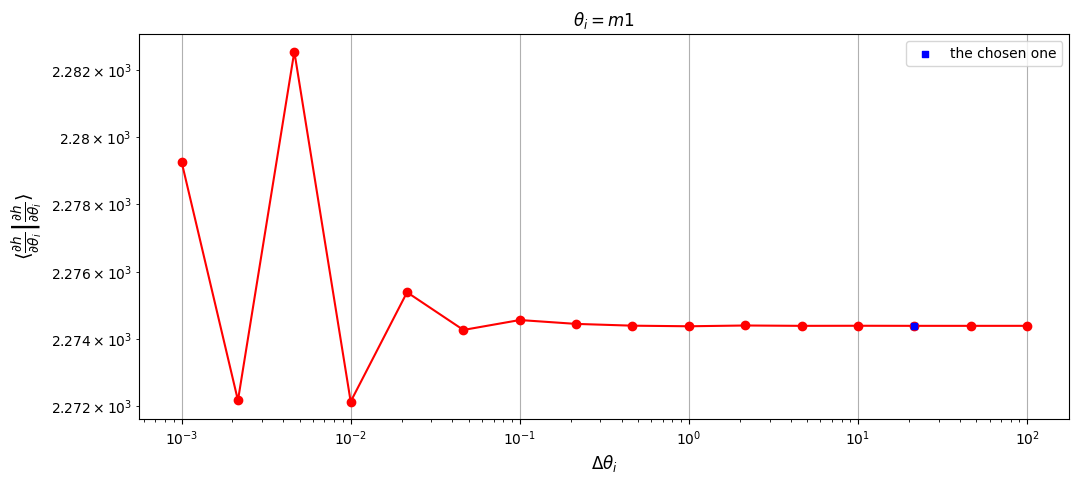

Gamma_ii for m2: 808587005676.1499
Gamma_ii for m2: 808588560751.2677
Gamma_ii for m2: 808587839810.9685
Gamma_ii for m2: 808584137919.1891
Gamma_ii for m2: 808598187469.5776
Gamma_ii for m2: 808636314662.4203
Gamma_ii for m2: 808559389346.3184
Gamma_ii for m2: 808468586686.4127
Gamma_ii for m2: 808702237762.1947
Gamma_ii for m2: 808897197179.6194
Gamma_ii for m2: 808346311445.7747
Gamma_ii for m2: 810616333376.7041
Gamma_ii for m2: 804233849852.7656
Gamma_ii for m2: 824049276094.7622
Gamma_ii for m2: 805728815763.9973
Gamma_ii for m2: 815820177362.2003
[np.float64(1.9231970290960038e-06), np.float64(8.916041816345855e-07), np.float64(4.5782394259494086e-06), np.float64(1.737519401634622e-05), np.float64(4.714998838330461e-05), np.float64(9.513873330210061e-05), np.float64(0.00011231439464803846), np.float64(0.00028892102045931196), np.float64(0.00024101878224383434), np.float64(0.0006814971826362827), np.float64(0.0028003653978614495), np.float64(0.007936104063646343), np.float64(0.02

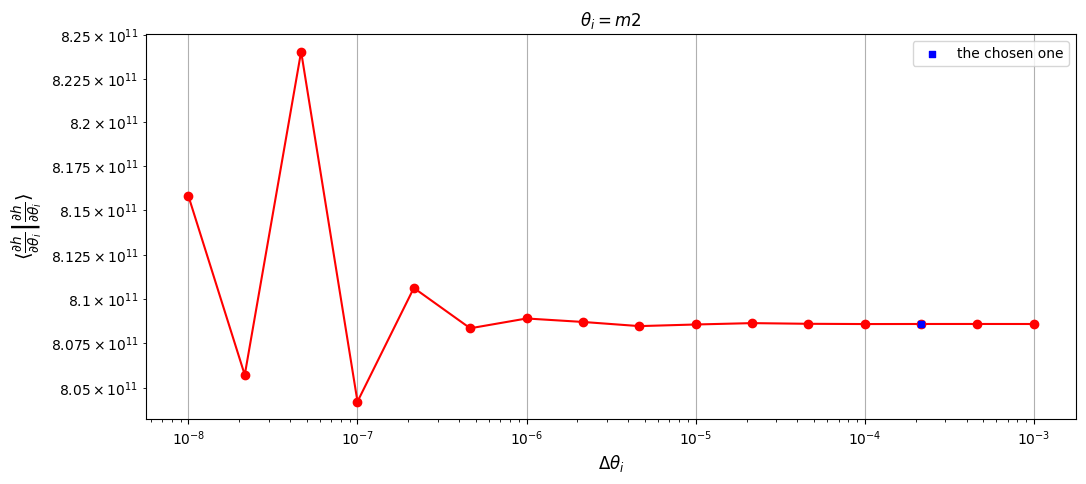

Gamma_ii for a: 51347021582505.78
Gamma_ii for a: 51346907208857.29
Gamma_ii for a: 51347018697161.79
Gamma_ii for a: 51347209905374.11
Gamma_ii for a: 51347367936175.305
Gamma_ii for a: 51349898335374.83
Gamma_ii for a: 51343481022152.92
Gamma_ii for a: 51337081501529.67
Gamma_ii for a: 51347060156274.02
Gamma_ii for a: 51353939045429.96
Gamma_ii for a: 51274909323142.266
Gamma_ii for a: 51290758572071.41
Gamma_ii for a: 52147715502294.62
Gamma_ii for a: 52488031277023.016
Gamma_ii for a: 50969803067074.67
Gamma_ii for a: 48583498773874.52
[np.float64(2.2274690864430128e-06), np.float64(2.171271231101924e-06), np.float64(3.723828669029595e-06), np.float64(3.0776806591477975e-06), np.float64(4.9277589275775666e-05), np.float64(0.00012498788734518026), np.float64(0.00012465688418729676), np.float64(0.00019433741121656573), np.float64(0.00013395056511345958), np.float64(0.001541294237882275), np.float64(0.0003090078870030747), np.float64(0.016433259289862907), np.float64(0.00648368335501

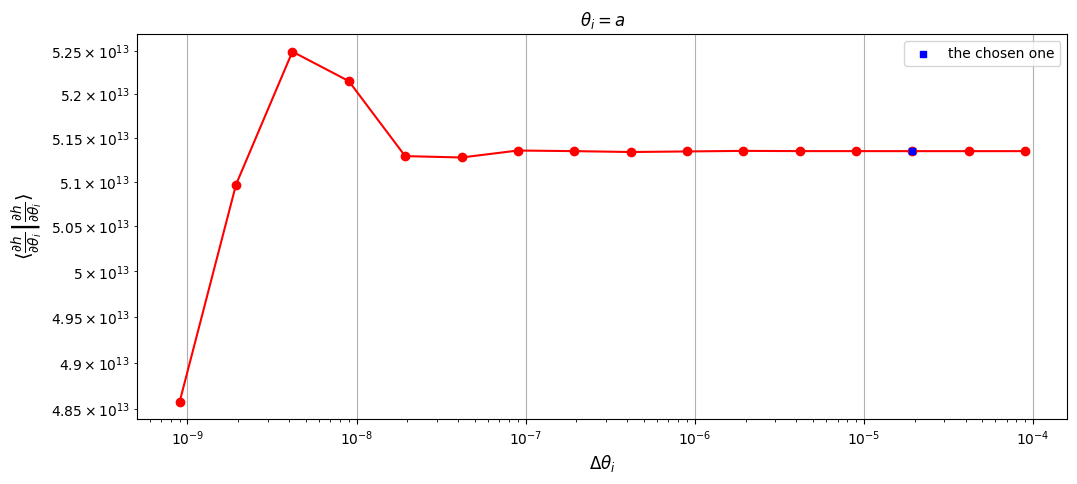

Gamma_ii for p0: 100006622592733.42
Gamma_ii for p0: 100006632233380.03
Gamma_ii for p0: 100006543702973.81
Gamma_ii for p0: 100006611073804.56
Gamma_ii for p0: 100006693492156.0
Gamma_ii for p0: 100006714808271.38
Gamma_ii for p0: 100006593009968.17
Gamma_ii for p0: 100005173217926.72
Gamma_ii for p0: 100008116783326.94
Gamma_ii for p0: 100001973804751.72
Gamma_ii for p0: 99995292788362.69
Gamma_ii for p0: 99972070691742.98
Gamma_ii for p0: 99961449511608.28
Gamma_ii for p0: 99938979547552.7
Gamma_ii for p0: 100242058086264.75
Gamma_ii for p0: 100590426071309.44
[np.float64(9.64000726159556e-08), np.float64(8.852461343098836e-07), np.float64(6.736637710908986e-07), np.float64(8.241283514084431e-07), np.float64(2.1314684134826697e-07), np.float64(1.2179027355824905e-06), np.float64(1.4197185963161914e-05), np.float64(2.9433264967844016e-05), np.float64(6.142857327208934e-05), np.float64(6.681330893416593e-05), np.float64(0.00023228584202588808), np.float64(0.00010625276230582984), np.f

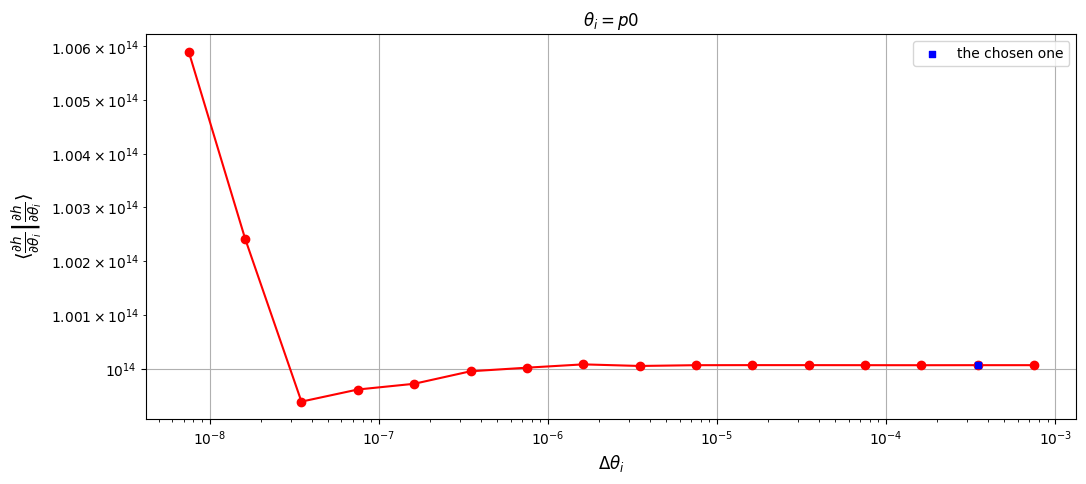

Gamma_ii for e0: 1547027518080702.2
Gamma_ii for e0: 1547029107043619.5
Gamma_ii for e0: 1547028471543392.2
Gamma_ii for e0: 1547027139867311.8
Gamma_ii for e0: 1547018721169684.8
Gamma_ii for e0: 1547061096355153.0
Gamma_ii for e0: 1547075013581498.5
Gamma_ii for e0: 1546995338307778.8
Gamma_ii for e0: 1547257109119817.0
Gamma_ii for e0: 1547295598604287.8
Gamma_ii for e0: 1547610072736661.8
Gamma_ii for e0: 1546551796215280.2
Gamma_ii for e0: 1555487050261245.0
Gamma_ii for e0: 1549771367346817.0
Gamma_ii for e0: 1516750503424230.2
Gamma_ii for e0: 1549829023604745.0
[np.float64(1.0271060253588352e-06), np.float64(4.1078767387906796e-07), np.float64(8.607968445946059e-07), np.float64(5.441884776051521e-06), np.float64(2.739076405455812e-05), np.float64(8.99583163280586e-06), np.float64(5.150324099030892e-05), np.float64(0.0001691837836745586), np.float64(2.4875327316557225e-05), np.float64(0.00020319984853672525), np.float64(0.0006842813308751204), np.float64(0.005744344862571546), n

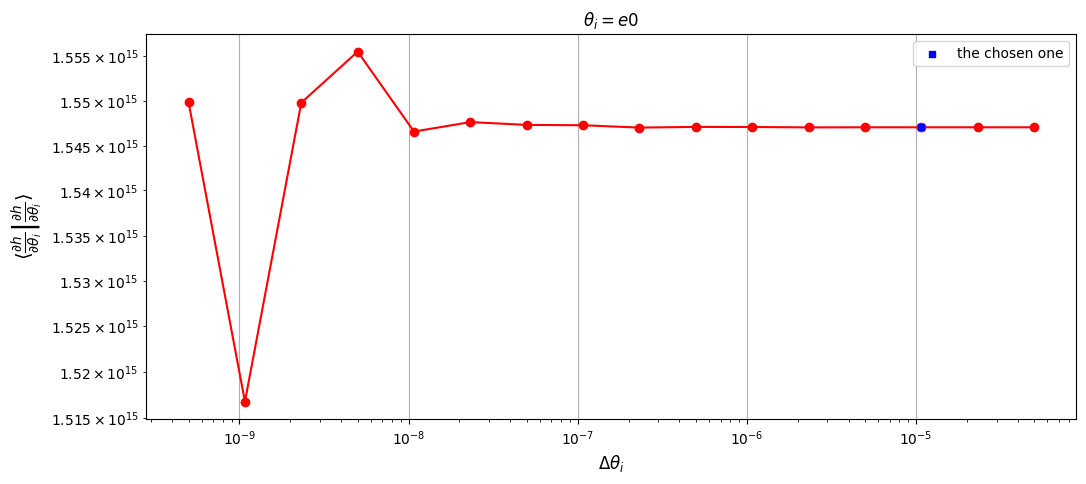

stable deltas: {'m1': 21.550872594838676, 'm2': 0.0002154832671287712, 'a': 1.9394190796920273e-05, 'p0': 0.00034806191308043417, 'e0': 1.0771218295172133e-05}
Time taken to compute stable deltas is 21.817901611328125 seconds
calculating Fisher matrix...
Finished derivatives
Calculated Fisher is *atleast* positive-definite.
Time taken to compute FM is 1.2874360084533691 seconds


In [22]:
x_best_fit_0PA = [1000302.895908148, 10.00184726535304, 0.9001985943994095, 7.498766598193502, 0.4999556656327664]

add_kwargs_0PA = {'chi2': 0.0, 'evolve_1PA': True, 'evolve_primary': False,
                      'evolve_2PA': True, 'deviation_included': False,
                      'dev_1': 0, 'dev_2': 0}

m1, m2, a, p0, e0= x_best_fit_0PA
wave_params = [m1, m2, a, p0, e0, ctx['Y0'],ctx['dist'],ctx['qS'],ctx['phiS'], ctx['qK'], ctx['phiK'], 
                    ctx['Phi_phi0'], ctx['Phi_theta0'], ctx['Phi_r0'],add_kwargs_0PA['chi2'],add_kwargs_0PA['evolve_1PA'],add_kwargs_0PA['evolve_primary'],
                    add_kwargs_0PA['evolve_2PA'], add_kwargs_0PA['deviation_included'],add_kwargs_0PA['dev_1'],add_kwargs_0PA['dev_2']]

    
param_names_to_infer = ['m1', 'm2', 'a', 'p0', 'e0']  
dim = len(param_names_to_infer)
param_names = param_names_to_infer
SNR = sef.SNRcalc_SEF(*wave_params,**emri_kwargs,use_gpu=use_gpu)
print("SNR: ", SNR)

param_dict = {
    'm1': wave_params[0],
    'm2': wave_params[1],
    'a': wave_params[2],
    'p0': wave_params[3],
    'e0': wave_params[4],
    'xI0': wave_params[5],
    'dist': wave_params[6],
    'qS': wave_params[7],
    'phiS': wave_params[8],
    'qK': wave_params[9],
    'phiK': wave_params[10],
    'Phi_phi0': wave_params[11],
    'Phi_theta0': wave_params[12],
    'Phi_r0': wave_params[13]}

Fisher_0PA = sef(wave_params = param_dict,param_names=param_names, add_param_args=add_kwargs_0PA,
            live_dangerously = False, stability_plot = True,der_order = 8, Ndelta = 16,return_derivatives = False)




In [23]:
def fishinv(M, Fisher, index_of_M=0):
    J = np.eye(len(Fisher))
    J[index_of_M, index_of_M] = M

    Fisher_lnM = J.T @ Fisher @ J
    print('Condition number of Fisher_lnM: ', np.linalg.cond(Fisher_lnM))
    Fisher_lnM_inv = np.linalg.inv(Fisher_lnM)  # Jacobian for Covariance = partial new/partial old, going from lnM -> M
    Fisher_inv = J.T @ Fisher_lnM_inv @ J
    return Fisher_inv

Covariance_fit_0PA = fishinv(m1, Fisher_0PA, index_of_M=0)

Condition number of Fisher_lnM:  2597155656.4795923


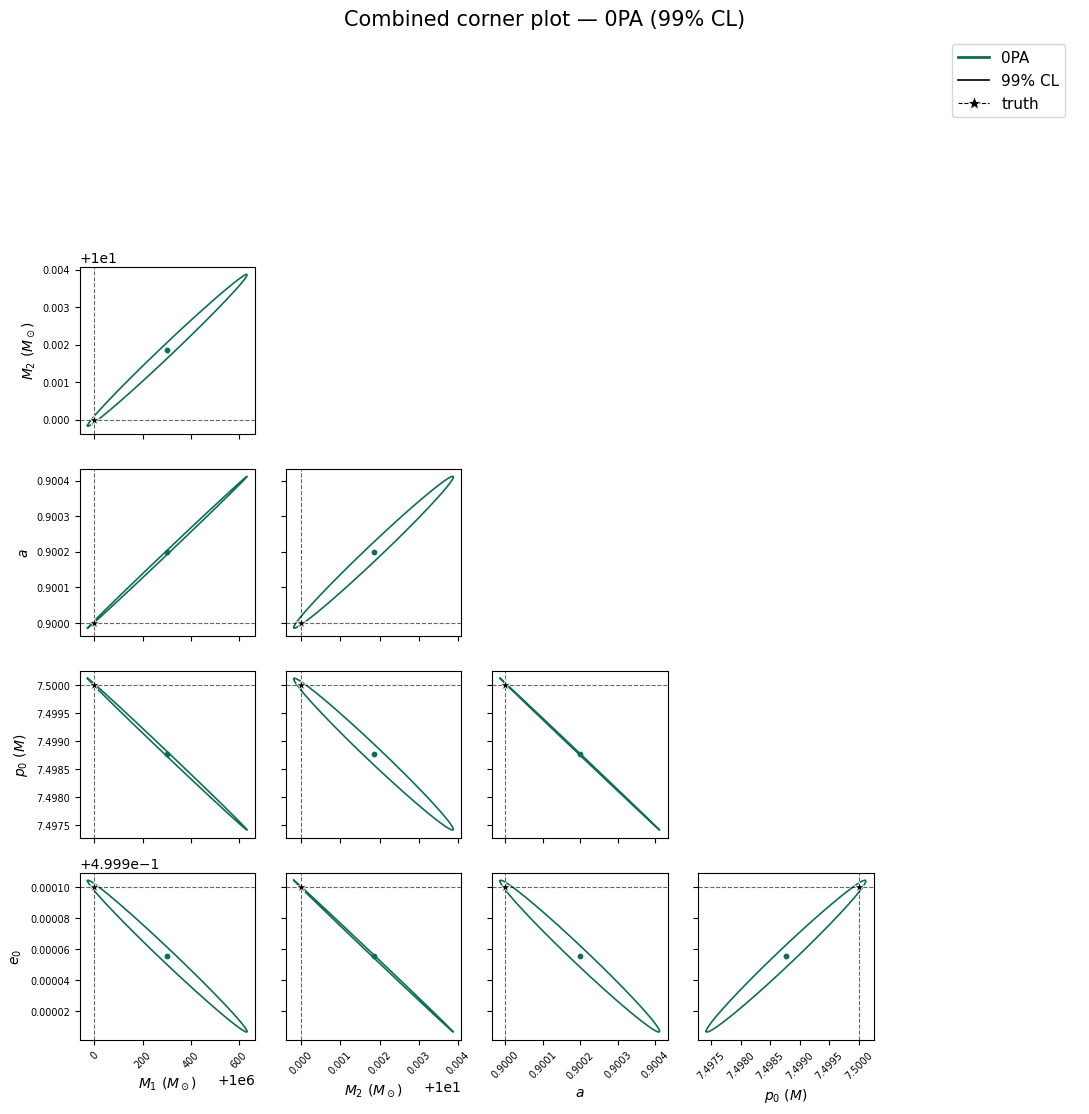

In [29]:
from scipy.stats import chi2  # ← was missing
import numpy as np
import matplotlib.pyplot as plt

# ── True injected parameters ──────────────────────────────────────────────────
signal_param = {
    "m1": 1e6, "m2": 10.0, "a": 0.9,
    "p0": 7.5, "e0": 0.5, "xI0": 1.0,
    "dist": 2.5, "qS": np.pi/4, "phiS": 1,
    "qK": 1, "phiK": np.pi/3,
    "Phi_phi0": 0.9, "Phi_theta0": 0.5, "Phi_r0": 4.0e-01,
}

true_params = np.array([
    signal_param["m1"], signal_param["m2"], signal_param["a"],
    signal_param["p0"], signal_param["e0"],
])

labels = [
    r'$M_1\ (M_\odot)$', r'$M_2\ (M_\odot)$', r'$a$',
    r'$p_0\ (M)$',        r'$e_0$',
]  # trimmed to match N_PARAMS_TOTAL=5; extend if needed

# ── Per-fit configuration ─────────────────────────────────────────────────────
fits = [
    ('0PA', np.asarray(x_best_fit_0PA), np.asarray(Covariance_fit_0PA), '#0F6E56', 9),
]

LEVELS         = (0.99,)          # 90 % CL  (was 0.99 but legend said "10%")
LEVEL_STYLES   = {0.99: '-'}
N_PARAMS_TOTAL = 5
TRUTH_COLOR    = '#000000'


# ── Confidence-ellipse helper ─────────────────────────────────────────────────
def draw_ellipses(ax, mean, cov, i, j, color, levels, styles):
    cov2  = cov[np.ix_([i, j], [i, j])]
    mean2 = mean[[i, j]]

    eigvals, eigvecs = np.linalg.eigh(cov2)
    order   = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    theta = np.linspace(0, 2 * np.pi, 400)
    for p in levels:
        chi2_val = chi2.ppf(p, df=2)
        r1 = np.sqrt(eigvals[0] * chi2_val)
        r2 = np.sqrt(eigvals[1] * chi2_val)
        ellipse = np.vstack([r1 * np.cos(theta), r2 * np.sin(theta)])
        ellipse = eigvecs @ ellipse + mean2[:, None]
        ax.plot(ellipse[0], ellipse[1], color=color, lw=1.2, ls=styles[p])


# ── Combined corner plot ──────────────────────────────────────────────────────
def combined_triangle_plot():
    D = N_PARAMS_TOTAL

    if len(true_params) != D:
        raise ValueError(
            f"true_params has {len(true_params)} entries; expected {D}.")
    if len(labels) != D:
        raise ValueError(
            f"labels has {len(labels)} entries; expected {D}.")

    fig, axes = plt.subplots(D, D, figsize=(2.2 * D, 2.2 * D))

    for i in range(D):
        for j in range(D):
            ax = axes[i, j]

            if j >= i:          # upper triangle + diagonal → hide
                ax.axis('off')
                continue

            for name, mean, cov, color, n in fits:
                if i >= n or j >= n:
                    continue
                draw_ellipses(ax, mean, cov, j, i, color, LEVELS, LEVEL_STYLES)
                ax.scatter(mean[j], mean[i], color=color, s=10, zorder=3)

            ax.axvline(true_params[j], color=TRUTH_COLOR, lw=0.8, ls='--', alpha=0.6)
            ax.axhline(true_params[i], color=TRUTH_COLOR, lw=0.8, ls='--', alpha=0.6)
            ax.scatter(true_params[j], true_params[i],
                       color=TRUTH_COLOR, marker='*', s=60, zorder=5,
                       edgecolor='white', linewidth=0.6)

            if i == D - 1:
                ax.set_xlabel(labels[j], fontsize=10)
                ax.tick_params(axis='x', labelrotation=45)
            else:
                ax.tick_params(axis='x', labelbottom=False)   # ← replaces set_xticklabels([])

            if j == 0:
                ax.set_ylabel(labels[i], fontsize=10)
            else:
                ax.tick_params(axis='y', labelleft=False)     # ← replaces set_yticklabels([])

            ax.tick_params(labelsize=7)

    cl_label = f'{int(LEVELS[0]*100)}% CL'
    legend_handles = [
        plt.Line2D([0], [0], color=color, lw=2, label=name)
        for name, _, _, color, _ in fits
    ]
    legend_handles.append(
        plt.Line2D([0], [0], color='black', lw=1.2,
                   ls=LEVEL_STYLES[LEVELS[0]], label=cl_label))
    legend_handles.append(
        plt.Line2D([0], [0], color=TRUTH_COLOR, marker='*',
                   ls='--', lw=0.8, markersize=10,
                   markeredgecolor='white', markeredgewidth=0.6,
                   label='truth'))

    fig.legend(handles=legend_handles, loc='upper right',
               bbox_to_anchor=(0.98, 0.98), fontsize=11, frameon=True)

    fit_names = ', '.join(name for name, *_ in fits)
    fig.suptitle(f'Combined corner plot — {fit_names} ({cl_label})',
                 fontsize=15, y=1.005)

    plt.tight_layout()
    plt.show()


combined_triangle_plot()